# 职业选手新版准星：2026-10-08 数据质量与组合分析

## tl;dr

使用 2026-10-05 官方 VRS Core，来源列出 **151 人**，其中 **133 人**有准星；99 条 cs2-v1 中 79 条页面在 10 月核验。HEROIC 来源名册有 6 人，需要核验，不能把采集完整等同于阵容有效。

主分析仅使用 **54 条 cs2-v1、静态十字、参考高度 960、10 月核验页面**。最常见的已提取外观组合为 **长度 2 / 间距偏移 1 / 粗细 2，无点、无描边、非 T 型、alpha 255**，22/54（40.7%），不等于多数完全相同。颜色另看 99 条新版记录，青色 21、绿色 18；探索性分组作为补充。

## Context & Methods

### Key Assumptions

- 页面 lastVerified 不是准星实际使用时间；新分享码可能来自转换。未进行全样本实战核验。
- 不合并旧单位、过渡编码或不同参考高度；不以显示分辨率推断准星高度。
- 主模型仅使用长度、间距偏移、粗细；RGB、点和描边保留为外观标签，未参与几何聚类。
- 基于匿名组合计数进行 IQR 缩放后的曼哈顿距离与 PAM；k=2–5 中选轮廓系数最高且每组至少 max(5,10%) 的方案。50 次固定种子的重复采样及特征权重、模板去重用于敏感性检查。
- 采样稳定性检查不等于独立来源验证；匿名输入不能检查队内相关性。

来源：[CS2Settings](https://cs2settings.com/players)、[官方 VRS](https://github.com/ValveSoftware/counter-strike_regional_standings/blob/main/live/2026/standings_global_2026_10_05.md)。第三方逐人数据保留在 work/，本 notebook 仅消费仓库公开聚合计数。


## Data

### 1. 加载公开计数并验证来源与分母

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "scripts/crosshair_analysis.py").exists())
sys.path.insert(0, str(root / "scripts"))
from crosshair_analysis import analyze, expand_joint, distances, medoids, canonical_hash

input_path = root / "data/aggregate/analysis/2026-10-08-crosshair.json"
review = json.loads(input_path.read_text())
snapshot = json.loads((root / "data/aggregate/2026-10-08.json").read_text())
assert review["input_metric_sha256"] == canonical_hash(snapshot["aggregate"])
assert review["collection"]["collection_complete"]
assert review["ranking_date"] == "2026-10-05"
assert sum(r["count"] for r in review["geometry_sample"]["combinations"]) == review["geometry_sample"]["valid_n"]
print("Snapshot:", review["snapshot_date"], "VRS:", review["ranking_date"])
print("Collection:", review["collection"])
print("Identity duplicates / domain errors / future page dates:", review["quality"]["identity_duplicate_n"], review["quality"]["invalid_values"], review["quality"]["future_page_date_n"])
print("Source roster size anomalies:", review["quality"]["roster_size_outliers"])
print("Recent-page main sample:", review["geometry_sample"]["valid_n"], "Reference height:", review["geometry_sample"]["reference_height"])
plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
figure_dir = root / "figures/analysis/2026-10-08"
figure_dir.mkdir(parents=True, exist_ok=True)


Snapshot: 2026-10-08 VRS: 2026-10-05
Collection: {'requested_core_teams': 30, 'successful_core_team_rosters': 30, 'expected_core_players': 151, 'successful_core_players': 151, 'collection_complete': True, 'incomplete_reasons': []}
Identity duplicates / domain errors / future page dates: 0 {} 0
Source roster size anomalies: [{'team': 'heroic', 'cohort_n': 6, 'crosshair_valid_n': 5, 'missing_n': 1}]
Recent-page main sample: 54 Reference height: 960


### 2. 覆盖与缺失

这是逐层筛选计数。最后 54 人只代表同格式、同形状、同参考高度的近期页面样本。

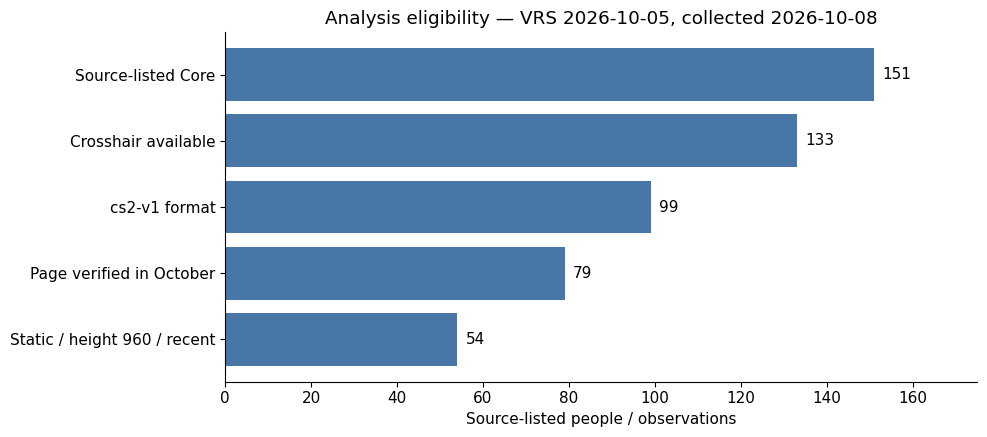

                         valid_n  missing_n  cohort_n
crosshair_format             133         18       151
crosshair_style              133         18       151
crosshair_size               133         18       151
crosshair_gap                133         18       151
crosshair_thickness          133         18       151
crosshair_screen_height      120         31       151
crosshair_dot                133         18       151
crosshair_outline_mode       133         18       151
crosshair_t_style            133         18       151
crosshair_alpha              133         18       151
crosshair_color_r            133         18       151
crosshair_color_g            133         18       151
crosshair_color_b            133         18       151


In [2]:
labels = ["Source-listed Core", "Crosshair available", "cs2-v1 format", "Page verified in October", "Static / height 960 / recent"]
counts = [review["cohort_n"], review["crosshair_valid_n"], review["native_format_n"], review["native_recent_page_n"], review["geometry_sample"]["valid_n"]]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(labels[::-1], counts[::-1], color="#4877a7")
for y, value in enumerate(counts[::-1]): ax.text(value+2, y, str(value), va="center")
ax.set_xlim(0, 175); ax.set_xlabel("Source-listed people / observations")
ax.set_title("Analysis eligibility — VRS 2026-10-05, collected 2026-10-08")
fig.tight_layout(); fig.savefig(figure_dir / "coverage.png", dpi=160); plt.show()
missing = pd.DataFrame(review["quality"]["field_completeness"]).T
print(missing.to_string())


### 3. 页面核验时间

4 条 cs2-v1 页面的核验日期早于系统更新，是时间语义或转换风险提示；不是 4 名选手已证实使用错误设置。旧格式缺少 screenHeight 属于结构性缺失，不应填充成显示高度。

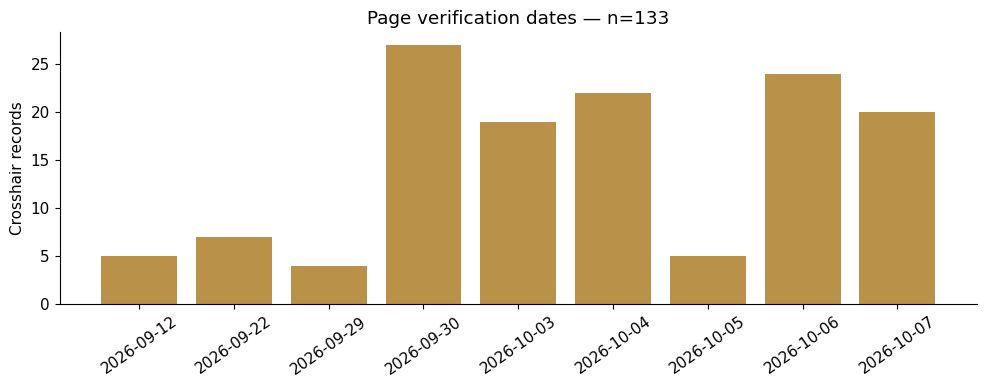

Pre-migration verified dates in native format: 4
Teams with missing crosshair data:
             team  cohort_n  crosshair_valid_n  missing_n
            3dmax         5                  4          1
               b8         5                  4          1
             faze         5                  3          2
      gamerlegion         5                  4          1
           heroic         6                  5          1
     inner-circle         5                  3          2
         jijiehao         5                  4          1
           legacy         5                  4          1
       luminosity         5                  3          2
            magic         5                  3          2
          nemesis         5                  4          1
           nemiga         5                  4          1
ninjas-in-pyjamas         5                  3          2


In [3]:
dates = review["quality"]["page_verified_dates"]["categories"]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(list(dates), list(dates.values()), color="#b99149")
ax.set_ylabel("Crosshair records"); ax.set_title("Page verification dates — n="+str(sum(dates.values())))
ax.tick_params(axis="x", rotation=35)
fig.tight_layout(); fig.savefig(figure_dir / "freshness.png", dpi=160); plt.show()
print("Pre-migration verified dates in native format:", review["quality"]["native_format_before_system_update_n"])
print("Teams with missing crosshair data:")
print(pd.DataFrame([r for r in review["quality"]["team_coverage"] if r["missing_n"]]).to_string(index=False))


## 最常见的起步设置与颜色

推荐依据是**真实出现的完整已提取外观组合**，不是各字段众数的拼接，也不是聚类人数。未提取字段不能认为相同。统一 cs2-v1、静态十字、参考高度 960、10 月页面核验：22/54 使用长度 2、间距偏移 1、粗细 2、无点、无描边、非 T 型、完全不透明。颜色不参与这套外观模板的排名。

颜色图使用全部 99 条 cs2-v1，页面日期不完全是 10 月；只比较精确 RGB，不把近似绿色主观合并。该模板的 22 条中，青色 6、绿色 4，其他颜色 12。几何推荐和总体颜色排名采用不同分母，不能相乘当作实际整套人数。


 crosshair_size  crosshair_gap  crosshair_thickness  crosshair_dot  crosshair_outline_mode  crosshair_t_style  crosshair_alpha  count
            2.0            1.0                  2.0          False                       0              False              255     22
            2.0            0.0                  2.0          False                       0              False              255      6
            4.0            2.0                  1.0          False                       0              False              255      6
            2.0            1.0                  1.0          False                       0              False              255      4
            3.0            2.0                  1.0          False                       0              False              255      4
            3.0            0.0                  2.0          False                       0              False              255      2
Colors within the most common appearance: {'valid_n': 22, 'cat

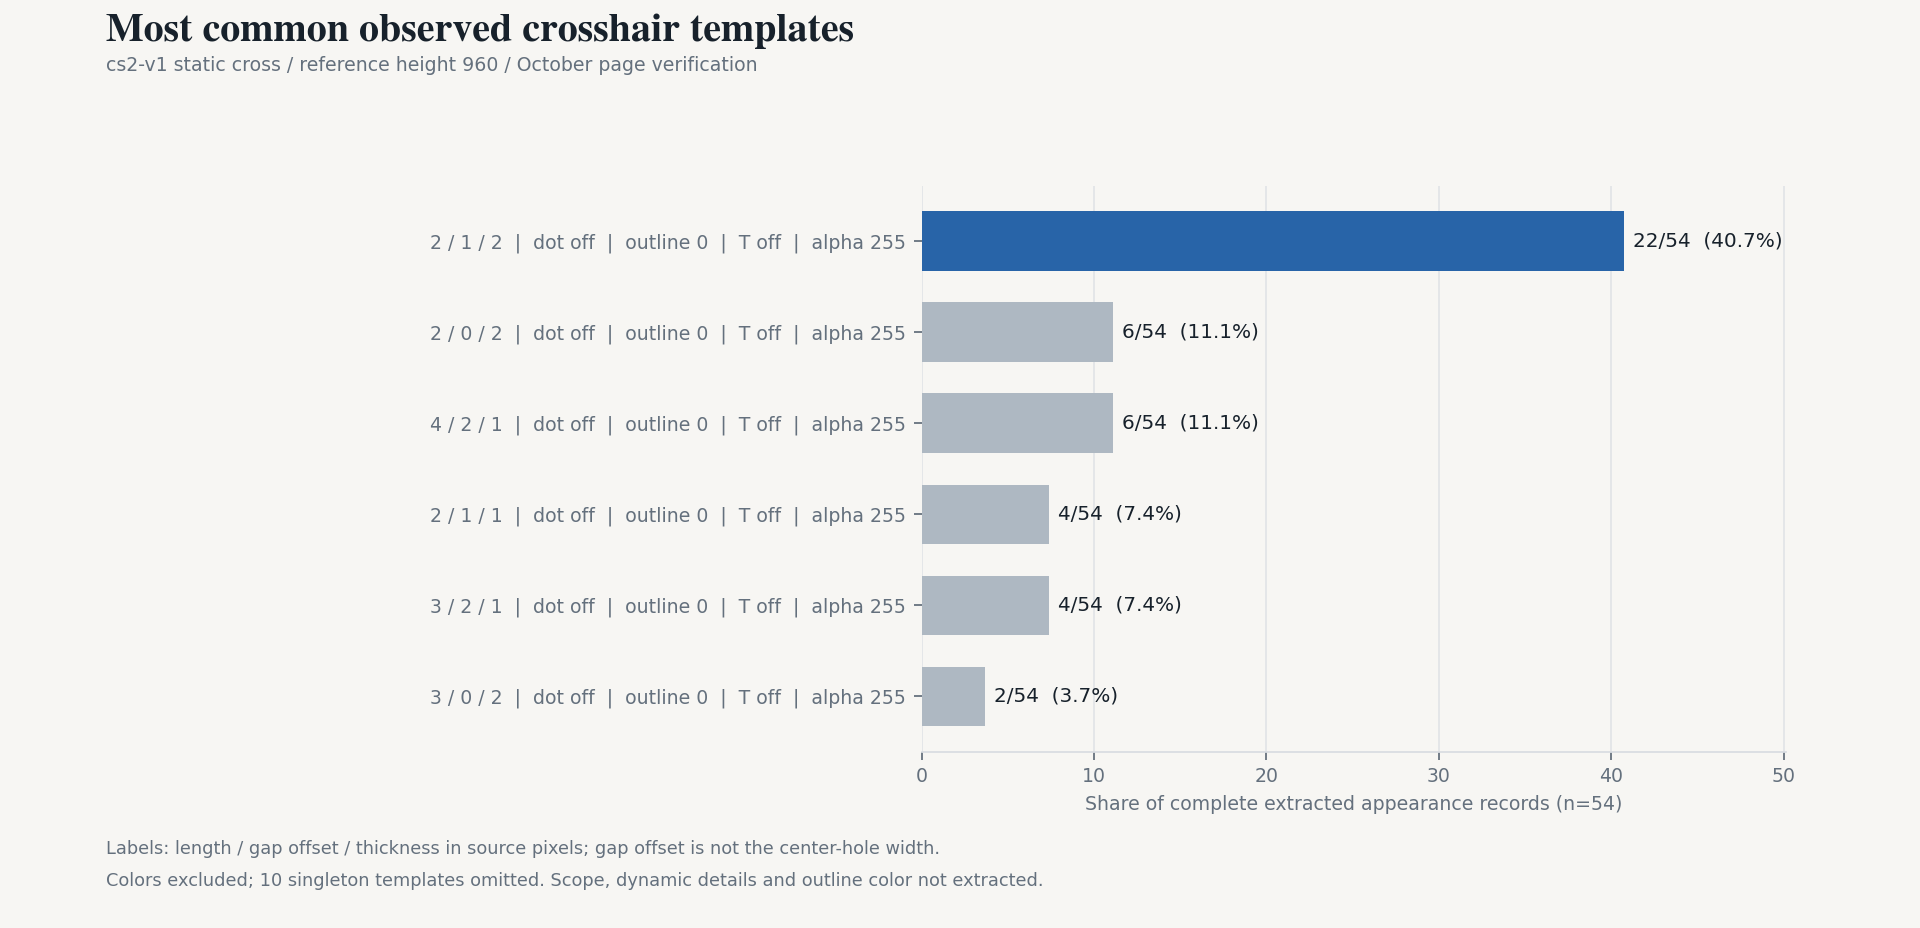

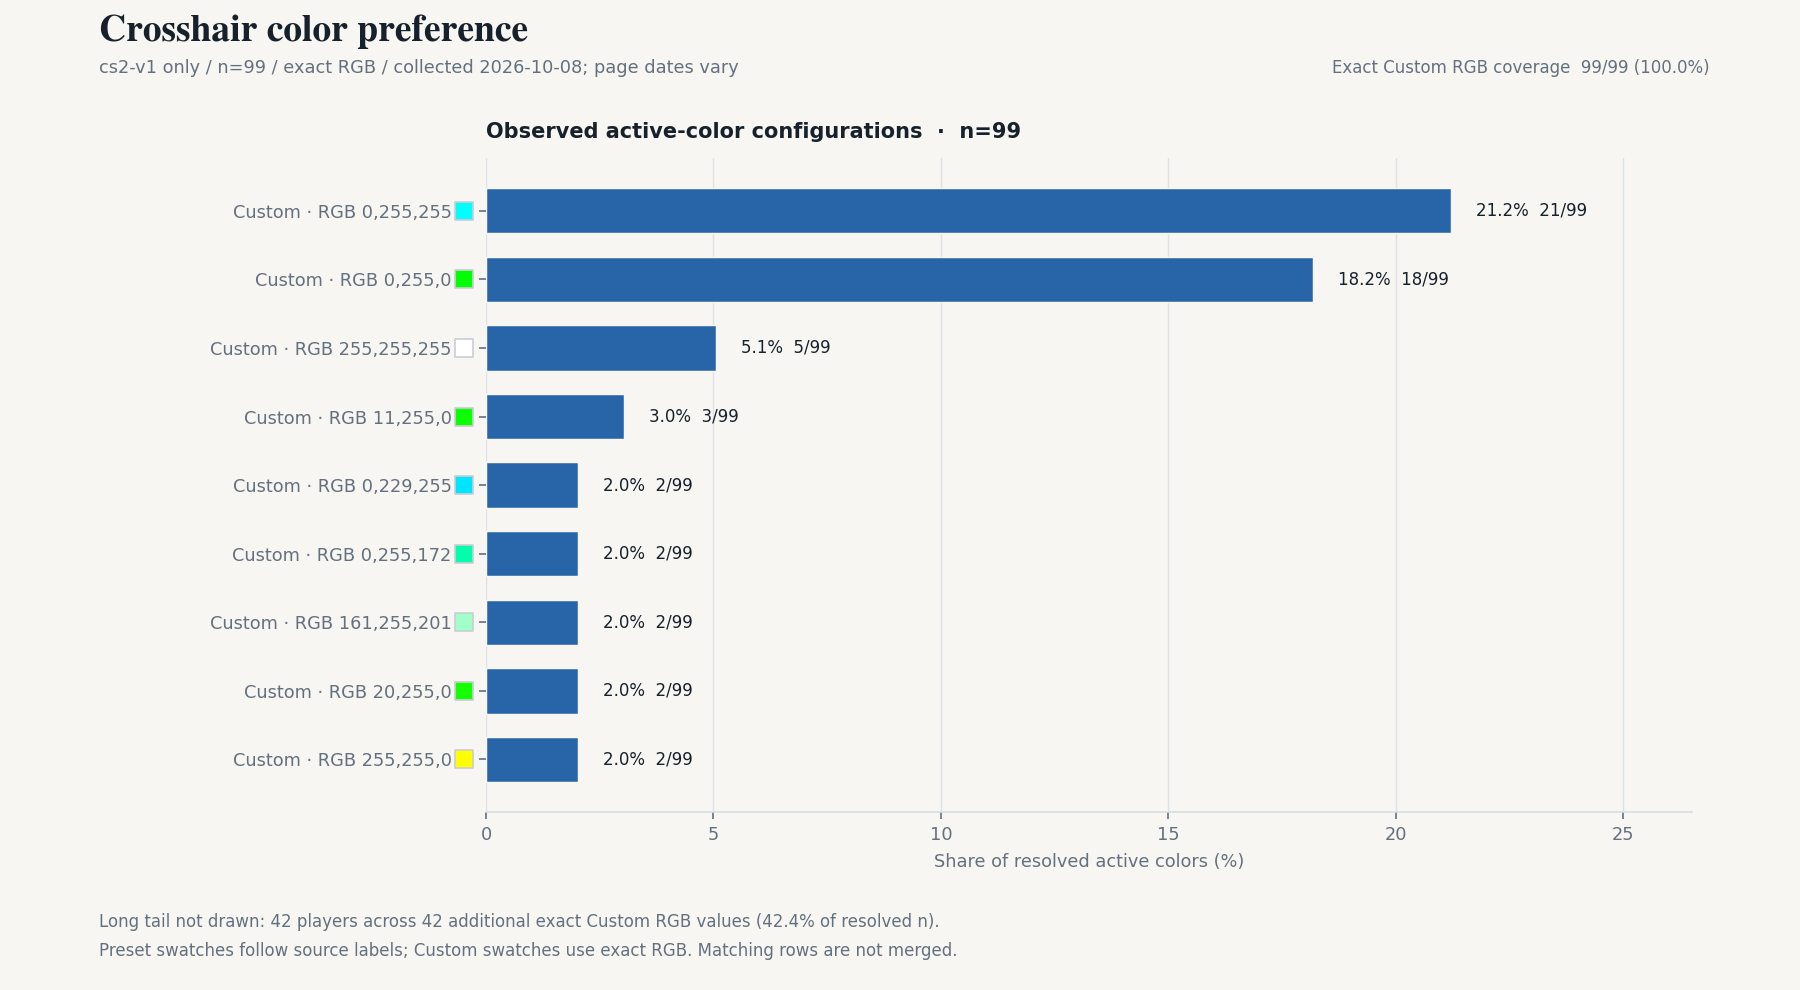

In [4]:
from crosshair_recommendation import render
from IPython.display import display, Image
appearance = review["popular_appearance"]
assert sum(r["count"] for r in appearance["combinations"]) + appearance["singleton_n"] == appearance["valid_n"]
assert appearance["valid_n"] + appearance["missing_n"] == appearance["sample_n"]
assert sum(review["native_colors"]["categories"].values()) == review["native_colors"]["valid_n"]
print(pd.DataFrame(appearance["combinations"]).to_string(index=False))
print("Colors within the most common appearance:", appearance["top_template_colors"])
print("October-page color sensitivity:", review["native_recent_colors"])
for chart in render(review, figure_dir):
    display(Image(filename=str(chart)))


## Results

### 4. 几何组合与关联

每个气泡是图中两参数相同的记录计数；第三参数在投影中合并，完整三参数组合见表。气泡面积表示人数。相关系数为描述性关联，无因果或命中率含义。

In [5]:
results = analyze(review)
assert results == review["analysis"], "Analysis changed; regenerate and review the published aggregate"
joint = pd.DataFrame(review["geometry_sample"]["combinations"])
print(joint.head(10).to_string(index=False))
print("Spearman correlations:")
print(pd.DataFrame(results["spearman"]).round(3).to_string())
# Two views keep gap and thickness visible without point-level identities.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, dimension in zip(axes, ["thickness", "gap_offset"]):
    cells = joint.groupby(["length", dimension], as_index=False)["count"].sum()
    ax.scatter(cells["length"], cells[dimension], s=cells["count"]*35, color="#4877a7", alpha=.7, edgecolor="#263d52")
    for row in cells.itertuples(index=False):
        if row.count >= 3: ax.text(row.length, getattr(row, dimension), str(row.count), ha="center", va="center", fontsize=10)
    ax.set_xlim(cells["length"].min()-.5, cells["length"].max()+.5)
    ax.set_xlabel("Bar length (px @ 960)"); ax.set_ylabel(dimension.replace("_", " ")+" (px @ 960)")
    ax.set_ylim(cells[dimension].min()-.7, cells[dimension].max()+.7)
    ax.set_title("Length vs "+dimension.replace("_", " "))
fig.suptitle("Recent-page static crosses — n="+str(results["sample_n"])+"; area = count")
fig.tight_layout(); fig.savefig(figure_dir / "geometry-combinations.png", dpi=160); plt.show()


 length  gap_offset  thickness  count
    2.0         1.0        2.0     22
    2.0         0.0        2.0      6
    4.0         2.0        1.0      6
    2.0         1.0        1.0      4
    3.0         2.0        1.0      4
    3.0         0.0        1.0      2
    3.0         0.0        2.0      2
    2.0         1.0        3.0      1
    2.0         2.0        2.0      1
    2.0         3.0        1.0      1
Spearman correlations:
            length  gap_offset  thickness
length       1.000       0.546     -0.550
gap_offset   0.546       1.000     -0.453
thickness   -0.550      -0.453      1.000


### 5. 探索性分组与敏感性

在保留合理组大小的候选中，两组的轮廓系数最高。组中心为真实出现的参数组合。41/13 是算法划分人数，不是恰好使用代表组合的人数。

In [6]:
print("Candidate partitions:")
print(pd.DataFrame(results["candidates"]).to_string(index=False))
print("Groups:")
print(pd.DataFrame(results.get("groups", [])).to_string(index=False))
print("Sensitivity:", results.get("sensitivity"))
print("All-page-date sensitivity:", results["all_date_sensitivity"])
if results["selected"]:
    x = expand_joint(review["geometry_sample"])
    d, _ = distances(x); centers, labels = medoids(d, results["selected"]["k"])
    fig, axes = plt.subplots(1, 3, figsize=(11, 4.2))
    for column, (ax, name) in enumerate(zip(axes, ["Length", "Gap offset", "Thickness"])):
        values = [x[labels==i, column] for i in range(results["selected"]["k"])]
        ax.boxplot(values, showfliers=True)
        ax.set_xticks(range(1, len(values)+1), ["Group "+str(i+1) for i in range(len(values))])
        ax.set_title(name); ax.set_ylabel("px @ 960")
    fig.suptitle("Exploratory geometry groups — n="+str(len(x)))
    fig.tight_layout(); fig.savefig(figure_dir / "exploratory-groups.png", dpi=160); plt.show()


Candidate partitions:
 k  silhouette             sizes  minimum_size_pass
 2      0.6596          [41, 13]               True
 3      0.5891      [31, 13, 10]               True
 4      0.6375   [31, 11, 10, 2]              False
 5      0.6678 [29, 7, 10, 2, 6]              False
Groups:
 group  count          medoid          median             min             max
     1     41 [2.0, 1.0, 2.0] [2.0, 1.0, 2.0] [2.0, 0.0, 1.0] [3.0, 3.0, 3.0]
     2     13 [4.0, 2.0, 1.0] [4.0, 2.0, 1.0] [3.0, 2.0, 1.0] [6.0, 5.0, 2.0]
Sensitivity: {'bootstrap_runs': 50, 'bootstrap_ari_median': 1.0, 'bootstrap_ari_p10': 0.7116, 'length_weighted_ari': 1.0, 'unique_template_silhouette': 0.6079, 'caveat': 'Bootstrap resamples anonymous parameter tuples, not teams; it cannot test independent-source truth or team dependence.'}
All-page-date sensitivity: {'sample_n': 66, 'spearman': {'length': {'length': 1.0, 'gap_offset': 0.4835, 'thickness': -0.5306}, 'gap_offset': {'length': 0.4835, 'gap_offset': 1.0, 'thi

## Takeaways

- 主样本确有短粗／较长细的分化线索；长度–粗细负相关在不限制页面日期的同形状、同高度样本中仍为负。
- 2/1/2 与 4/2/1 可作为图鉴候选代表，但探索性两组并不证明存在两种天然流派。重复模板、来源转换与单来源覆盖会影响分组。
- 18 名成员没有设置，缺失集中于若干队伍；HEROIC 6 人名册有一名无角色、无设置者待核验。不能把样本当成完整、独立确认的现役阵容。
- 动态参数、描边颜色、瞄准镜信息尚未提取；颜色与装饰标签尚未关联到这些公开几何分组，实际渲染与 ProCrosshairs 全样本核验未完成。
- 下一步应核验名册异常与主要代表准星，再完善解码和渲染。当前结果支持文章准备和风格候选，尚不支持战绩、命中率或选择动机结论。

所有表格和图仅含公开聚合值；原始玩家级数据不进入 notebook 输出。
